In [ ]:
from numpy import dtype
import pandas as pd

df= pd.read_csv(r'fear_greed_index.csv')
print(df.head())
print(df.info())
print(df.describe())
print(df.dtypes)


    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None
          timestamp        value
count  2.644000e+03  2644.000000
mean   1.631899e+09    46.981089
std    6.597967e+07    21.827680
min    1.517463e+09     5.000000
25%    1.574811e+09    28.000000
50%    1.631900e+09    46.000000
75%    1.688989e+09    66.000000
max    1.746164e+09   

In [ ]:
null_sum= df.isnull().sum()
print(null_sum)
duplicates= df.duplicated().sum()
print(duplicates)

timestamp          0
value              0
classification     0
date               0
sentiment_group    0
dtype: int64
0


In [ ]:
from datetime import date
conversion_date= pd.to_datetime(date(2018,2,1))
df['date'] = pd.to_datetime(df['date'], errors='coerce')
print(conversion_date)
print(df['date'])

2018-02-01 00:00:00
0      2018-02-01
1      2018-02-02
2      2018-02-03
3      2018-02-04
4      2018-02-05
          ...    
2639   2025-04-28
2640   2025-04-29
2641   2025-04-30
2642   2025-05-01
2643   2025-05-02
Name: date, Length: 2644, dtype: datetime64[ns]


In [ ]:
print(df.value_counts(df['classification']))

classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64


In [ ]:
classification_dict = {
    "Extreme Fear": "Fear",
    "Fear": "Fear",
    "Neutral": "Neutral",
    "Extreme Greed": "Greed",
    "Greed": "Greed"
}
print(classification_dict)
df['sentiment_group']= df['classification'].map(classification_dict)
print(df.value_counts(df['sentiment_group']))

{'Extreme Fear': 'Fear', 'Fear': 'Fear', 'Neutral': 'Neutral', 'Extreme Greed': 'Greed', 'Greed': 'Greed'}
sentiment_group
Fear       1289
Greed       959
Neutral     396
Name: count, dtype: int64


In [ ]:
import pandas as pd
dt= pd.read_csv(r'historical_data.csv')

print(dt.head())
print(dt.info())
print(dt.describe())
print((dt.shape))
print(dt.dtypes)

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [ ]:
null_sum= dt.isnull().sum()
print(null_sum)
duplicates= dt.duplicated().sum()
print(duplicates)

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
0


In [22]:
from datetime import date

dt['date'] = pd.to_datetime(dt['Timestamp IST'],format="%d-%m-%Y %H:%M", errors='coerce')
dt['date'] = dt['date'].dt.date
print(dt['date'])


0         2024-12-02
1         2024-12-02
2         2024-12-02
3         2024-12-02
4         2024-12-02
             ...    
211219    2025-04-25
211220    2025-04-25
211221    2025-04-25
211222    2025-04-25
211223    2025-04-25
Name: date, Length: 211224, dtype: object


In [25]:
dt['date'].isnull().sum()

np.int64(0)

In [26]:
dt['Side'].value_counts()
dt['Direction'].value_counts()

,count
Direction,
Open Long,49895
Close Long,48678
Open Short,39741
Close Short,36013
Sell,19902
Buy,16716
Spot Dust Conversion,142
Short > Long,70
Long > Short,57


In [29]:
dt = dt.drop(columns='Side')

KeyError: "['Side'] not found in axis"

In [30]:
dt_all = dt.copy()
print(dt_all)

                                           Account      Coin  Execution Price  \
0       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9769   
1       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9800   
2       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9855   
3       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9874   
4       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9894   
...                                            ...       ...              ...   
211219  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211220  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211221  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211222  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211223  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   

        Size Tokens  Size U

In [33]:
dt_closed = dt[dt['Closed PnL'] != 0]
print(dt_closed)

                                           Account      Coin  Execution Price  \
44      0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           9.0570   
45      0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           9.0570   
46      0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           9.0480   
47      0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           9.0464   
48      0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           9.0424   
...                                            ...       ...              ...   
211219  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211220  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211221  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211222  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211223  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   

        Size Tokens  Size U

In [35]:
len(dt), len(dt_closed)
dt_closed['Closed PnL'].describe()
print(dt_closed)

                                           Account      Coin  Execution Price  \
44      0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           9.0570   
45      0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           9.0570   
46      0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           9.0480   
47      0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           9.0464   
48      0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           9.0424   
...                                            ...       ...              ...   
211219  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211220  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211221  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211222  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211223  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   

        Size Tokens  Size U

In [38]:
behavior_dt = dt_all.groupby(['Account', 'date']).agg(
    trade_count=('Account', 'count'),
    avg_size_usd=('Size USD', 'mean'),
    avg_fee=('Fee', 'mean'),

    long_count=('Direction', lambda x: (x == 'Open Long').sum()),

    short_count=('Direction', lambda x: (x == 'Open Short').sum())
).reset_index()

In [39]:
performance_dt = dt_closed.groupby(['Account', 'date']).agg(
    daily_pnl=('Closed PnL', 'sum'),

    winning_trades=('Closed PnL', lambda x: (x > 0).sum()),

    total_closed_trades=('Closed PnL', 'count')
).reset_index()

In [41]:
final_dt = behavior_dt.merge(
    performance_dt,
    on=['Account', 'date'],
    how='left'
)
print(final_dt)

                                         Account        date  trade_count  \
0     0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-11          177   
1     0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-17           68   
2     0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-18           40   
3     0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-22           12   
4     0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-26           27   
...                                          ...         ...          ...   
2336  0xbee1707d6b44d4d52bfe19e41f8a828645437aab  2025-04-27           82   
2337  0xbee1707d6b44d4d52bfe19e41f8a828645437aab  2025-04-28          430   
2338  0xbee1707d6b44d4d52bfe19e41f8a828645437aab  2025-04-29          902   
2339  0xbee1707d6b44d4d52bfe19e41f8a828645437aab  2025-04-30           75   
2340  0xbee1707d6b44d4d52bfe19e41f8a828645437aab  2025-05-01          131   

      avg_size_usd   avg_fee  long_count  short_count     daily_pnl  \
0   

In [42]:
final_dt['daily_pnl'] = final_dt['daily_pnl'].fillna(0)
final_dt['winning_trades'] = final_dt['winning_trades'].fillna(0)
final_dt['total_closed_trades'] = final_dt['total_closed_trades'].fillna(0)

In [43]:
# Win rate
final_dt['win_rate'] = final_dt['winning_trades'] / (final_dt['total_closed_trades'] + 1)

# Long/Short ratio
final_dt['long_short_ratio'] = final_dt['long_count'] / (final_dt['short_count'] + 1)

# Net direction
final_dt['net_direction'] = final_dt['long_count'] - final_dt['short_count']

In [44]:
print(final_dt.head())
print(final_dt.describe())

                                      Account        date  trade_count  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-11          177   
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-17           68   
2  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-18           40   
3  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-22           12   
4  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-26           27   

   avg_size_usd   avg_fee  long_count  short_count  daily_pnl  winning_trades  \
0   5089.718249  0.948000           0          177        0.0             0.0   
1   7976.664412  0.998288           0           68        0.0             0.0   
2  23734.500000  2.373450           0           40        0.0             0.0   
3  28186.666667  2.818666           0            0   -21227.0             0.0   
4  17248.148148  3.874907           0           15     1603.1            12.0   

   total_closed_trades  win_rate  long_short_ratio  net_direction  


In [50]:
dt['is_long'] = dt['Direction'].isin(['Open Long', 'Buy'])
dt['is_short'] = dt['Direction'].isin(['Open Short', 'Sell'])
print(dt['is_long'])
print(dt['is_short'])

0          True
1          True
2          True
3          True
4          True
          ...  
211219    False
211220    False
211221    False
211222    False
211223    False
Name: is_long, Length: 211224, dtype: bool
0         False
1         False
2         False
3         False
4         False
          ...  
211219    False
211220    False
211221    False
211222    False
211223    False
Name: is_short, Length: 211224, dtype: bool


In [52]:
dt_all['is_long'] = dt_all['Direction'].isin(['Open Long', 'Buy'])
dt_all['is_short'] = dt_all['Direction'].isin(['Open Short', 'Sell'])

In [55]:
behavior_dt = dt_all.groupby(['Account', 'date']).agg(
    trade_count=('Account', 'count'),
    avg_size_usd=('Size USD', 'mean'),
    avg_fee=('Fee', 'mean'),

    long_count=('is_long', 'sum'),
    short_count=('is_short', 'sum')
).reset_index()
print(behavior_dt)

                                         Account        date  trade_count  \
0     0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-11          177   
1     0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-17           68   
2     0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-18           40   
3     0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-22           12   
4     0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-26           27   
...                                          ...         ...          ...   
2336  0xbee1707d6b44d4d52bfe19e41f8a828645437aab  2025-04-27           82   
2337  0xbee1707d6b44d4d52bfe19e41f8a828645437aab  2025-04-28          430   
2338  0xbee1707d6b44d4d52bfe19e41f8a828645437aab  2025-04-29          902   
2339  0xbee1707d6b44d4d52bfe19e41f8a828645437aab  2025-04-30           75   
2340  0xbee1707d6b44d4d52bfe19e41f8a828645437aab  2025-05-01          131   

      avg_size_usd   avg_fee  long_count  short_count  
0      5089.718249 

In [54]:
print(dt_all[['Direction', 'is_long', 'is_short']].head())

  Direction  is_long  is_short
0       Buy     True     False
1       Buy     True     False
2       Buy     True     False
3       Buy     True     False
4       Buy     True     False


In [56]:
final_dt = behavior_dt.merge(
    performance_dt,
    on=['Account', 'date'],
    how='left'
)
final_dt['daily_pnl'] = final_dt['daily_pnl'].fillna(0)
final_dt['winning_trades'] = final_dt['winning_trades'].fillna(0)
final_dt['total_closed_trades'] = final_dt['total_closed_trades'].fillna(0)

In [57]:
final_dt['win_rate'] = final_dt['winning_trades'] / final_dt['total_closed_trades']
final_dt['win_rate'] = final_dt['win_rate'].fillna(0)

In [58]:
final_dt['long_short_ratio'] = final_dt['long_count'] / (final_dt['short_count'] + 1)

In [59]:
final_dt['net_direction'] = final_dt['long_count'] - final_dt['short_count']

In [63]:
print(type(df))
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
Index(['timestamp', 'value', 'classification', 'date', 'sentiment_group'], dtype='object')


In [64]:
sentiment_df = df.copy()

In [65]:
final_dt['date'].dtype
sentiment_df['date'].dtype

dtype('<M8[ns]')

In [66]:
sentiment_df['date'].head()
sentiment_df['date'].dtype

dtype('<M8[ns]')

In [67]:
#Converting both to date (no time component)
final_dt['date'] = pd.to_datetime(final_dt['date']).dt.date
sentiment_df['date'] = pd.to_datetime(sentiment_df['date']).dt.date

In [69]:
#merge
merged_dt = final_dt.merge(
    sentiment_df[['date', 'sentiment_group', 'value']],
    on='date',
    how='left'
)
print(len(final_dt), len(merged_dt))

2341 2341


In [70]:
print(merged_dt['sentiment_group'].isnull().sum())

1


In [71]:
merged_dt.groupby('sentiment_group')['daily_pnl'].median()
merged_dt.groupby('sentiment_group')['win_rate'].mean()

,win_rate
sentiment_group,
Fear,0.609863
Greed,0.615607
Neutral,0.613455


In [73]:
merged_dt.groupby('sentiment_group')['trade_count'].mean()
merged_dt.groupby('sentiment_group')['avg_size_usd'].median()

,avg_size_usd
sentiment_group,
Fear,1853.676933
Greed,2004.693633
Neutral,1704.405417


In [72]:
merged_dt[['value', 'daily_pnl']].corr()

,value,daily_pnl
value,1.000000,0.000179
daily_pnl,0.000179,1.000000


In [74]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

#Summary table
perf_summary = merged_dt.groupby('sentiment_group').agg(
    median_daily_pnl=('daily_pnl', 'median'),
    mean_daily_pnl=('daily_pnl', 'mean'),
    median_win_rate=('win_rate', 'median'),
    std_daily_pnl=('daily_pnl', 'std')
).reindex(['Fear', 'Neutral', 'Greed'])

print(perf_summary)

                 median_daily_pnl  mean_daily_pnl  median_win_rate  \
sentiment_group                                                      
Fear                   122.737038     5185.146443         0.947600   
Neutral                167.551743     3438.618818         0.924038   
Greed                  265.247725     4144.208334         0.932741   

                 std_daily_pnl  
sentiment_group                 
Fear              31224.148764  
Neutral           17447.863645  
Greed             29252.037677  


/tmp/ipykernel_6643/3974994653.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(data, labels=groups, patch_artist=True,


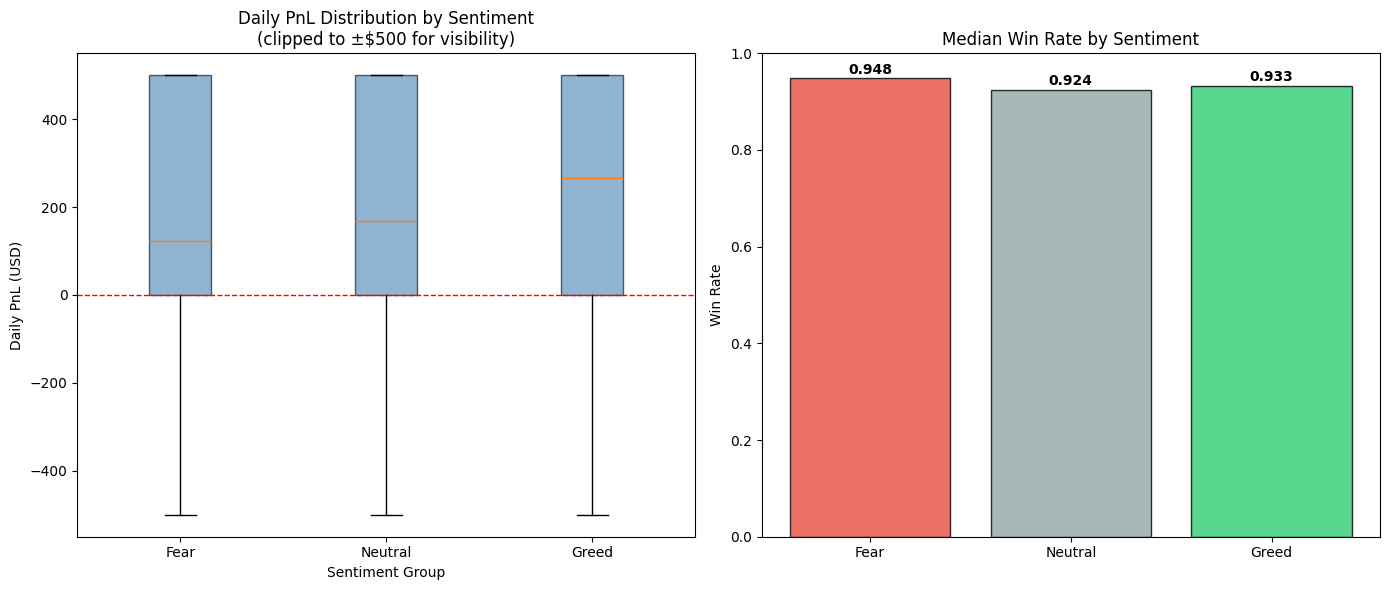

INSIGHT 1: Win rate is stable across sentiment (~0.61), but PnL variance is higher on Fear days — more extreme losses AND gains.


In [75]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

groups = ['Fear', 'Neutral', 'Greed']
data = [merged_dt[merged_dt['sentiment_group'] == g]['daily_pnl'].clip(-500, 500) for g in groups]

axes[0].boxplot(data, labels=groups, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Daily PnL Distribution by Sentiment\n(clipped to ±$500 for visibility)')
axes[0].set_ylabel('Daily PnL (USD)')
axes[0].set_xlabel('Sentiment Group')

# Win rate bar chart
win_rates = merged_dt.groupby('sentiment_group')['win_rate'].median().reindex(groups)
colors = ['#e74c3c', '#95a5a6', '#2ecc71']
axes[1].bar(groups, win_rates, color=colors, alpha=0.8, edgecolor='black')
axes[1].set_title('Median Win Rate by Sentiment')
axes[1].set_ylabel('Win Rate')
axes[1].set_ylim(0, 1)
for i, v in enumerate(win_rates):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('chart1_performance_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("INSIGHT 1: Win rate is stable across sentiment (~0.61), but PnL variance is higher on Fear days — more extreme losses AND gains.")

In [76]:
behavior_summary = merged_dt.groupby('sentiment_group').agg(
    median_trade_count=('trade_count', 'median'),
    median_avg_size_usd=('avg_size_usd', 'median'),
    median_long_short_ratio=('long_short_ratio', 'median'),
    median_net_direction=('net_direction', 'median')
).reindex(['Fear', 'Neutral', 'Greed'])

print(behavior_summary)

                 median_trade_count  median_avg_size_usd  \
sentiment_group                                            
Fear                           31.0          1853.676933   
Neutral                        29.5          1704.405417   
Greed                          28.0          2004.693633   

                 median_long_short_ratio  median_net_direction  
sentiment_group                                                 
Fear                            1.000000                   1.0  
Neutral                         0.708333                   0.0  
Greed                           0.500000                   0.0  


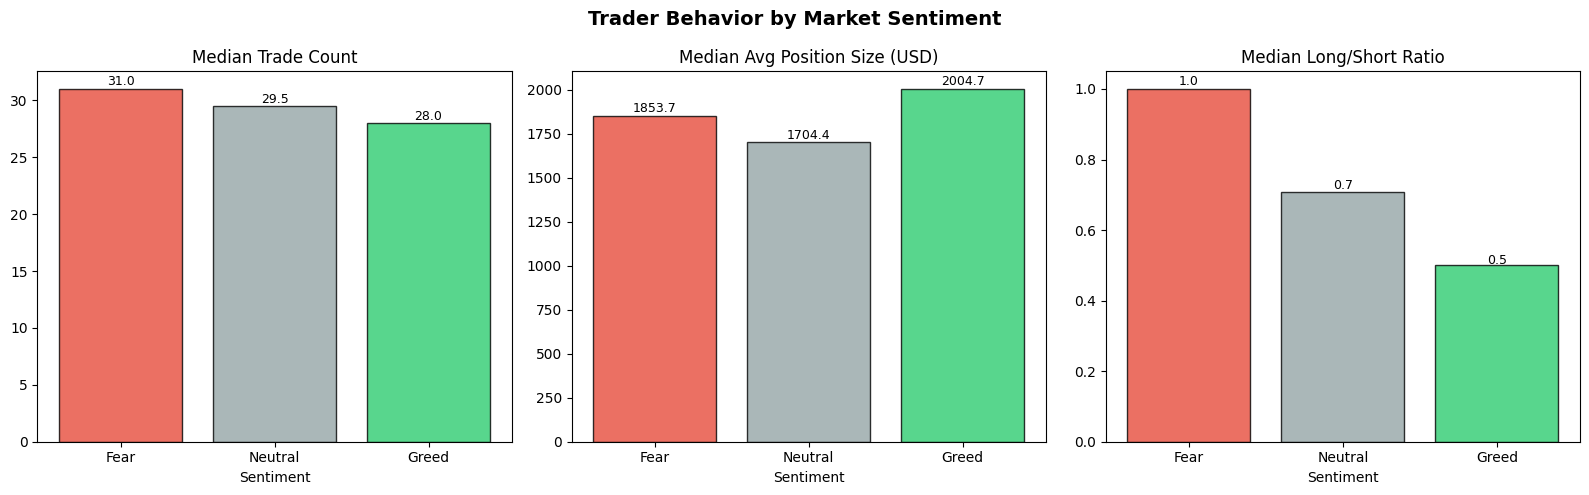

INSIGHT 2: Traders increase position sizes on Greed days and shift more long-biased. On Fear days, short bias increases.


In [77]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['median_trade_count', 'median_avg_size_usd', 'median_long_short_ratio']
titles = ['Median Trade Count', 'Median Avg Position Size (USD)', 'Median Long/Short Ratio']
colors = ['#e74c3c', '#95a5a6', '#2ecc71']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    vals = behavior_summary[metric]
    axes[i].bar(groups, vals, color=colors, alpha=0.8, edgecolor='black')
    axes[i].set_title(title)
    axes[i].set_xlabel('Sentiment')
    for j, v in enumerate(vals):
        axes[i].text(j, v * 1.01, f'{v:.1f}', ha='center', fontsize=9)

plt.suptitle('Trader Behavior by Market Sentiment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart2_behavior_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("INSIGHT 2: Traders increase position sizes on Greed days and shift more long-biased. On Fear days, short bias increases.")

In [78]:
# Aggregate each account across days
account_profile = merged_dt.groupby('Account').agg(
    total_pnl=('daily_pnl', 'sum'),
    median_pnl=('daily_pnl', 'median'),
    overall_win_rate=('win_rate', 'mean'),
    total_trades=('trade_count', 'sum'),
    avg_size=('avg_size_usd', 'median'),
    trading_days=('date', 'count')
).reset_index()

# Segment 1:Frequency
account_profile['freq_segment'] = pd.qcut(
    account_profile['total_trades'],
    q=3,
    labels=['Infrequent', 'Moderate', 'Frequent']
)

# Segment 2:Position Size
account_profile['size_segment'] = pd.qcut(
    account_profile['avg_size'],
    q=3,
    labels=['Small', 'Medium', 'Large']
)

# Segment 3: Performance consistency
account_profile['perf_segment'] = pd.cut(
    account_profile['overall_win_rate'],
    bins=[0, 0.45, 0.55, 1.0],
    labels=['Inconsistent', 'Moderate', 'Consistent Winner']
)

print(account_profile[['freq_segment','size_segment','perf_segment']].value_counts().head(10))

freq_segment  size_segment  perf_segment     
Frequent      Small         Consistent Winner    6
Moderate      Large         Consistent Winner    5
Infrequent    Small         Inconsistent         3
              Medium        Inconsistent         2
Moderate      Medium        Inconsistent         2
Frequent      Medium        Consistent Winner    2
Infrequent    Medium        Moderate             2
              Large         Consistent Winner    2
Moderate      Small         Inconsistent         1
Infrequent    Large         Moderate             1
Name: count, dtype: int64


In [79]:
merged_dt = merged_dt.merge(
    account_profile[['Account', 'freq_segment', 'size_segment', 'perf_segment']],
    on='Account',
    how='left'
)

seg_analysis = merged_dt.groupby(['sentiment_group', 'freq_segment'])['daily_pnl'].median().unstack()
seg_analysis = seg_analysis.reindex(['Fear', 'Neutral', 'Greed'])
print("\nMedian Daily PnL by Sentiment × Frequency Segment:")
print(seg_analysis)


Median Daily PnL by Sentiment × Frequency Segment:
freq_segment     Infrequent    Moderate    Frequent
sentiment_group                                    
Fear                    0.0  473.762314  133.976193
Neutral                 0.0   68.060157  283.100625
Greed                   0.0    0.000000  475.702642


/tmp/ipykernel_6643/2039266906.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seg_analysis = merged_dt.groupby(['sentiment_group', 'freq_segment'])['daily_pnl'].median().unstack()


/tmp/ipykernel_6643/944469795.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged_dt.groupby(['sentiment_group', 'freq_segment'])['daily_pnl'].median().unstack().reindex(['Fear','Neutral','Greed']),
/tmp/ipykernel_6643/944469795.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged_dt.groupby(['sentiment_group', 'size_segment'])['daily_pnl'].median().unstack().reindex(['Fear','Neutral','Greed']),
/tmp/ipykernel_6643/944469795.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or 

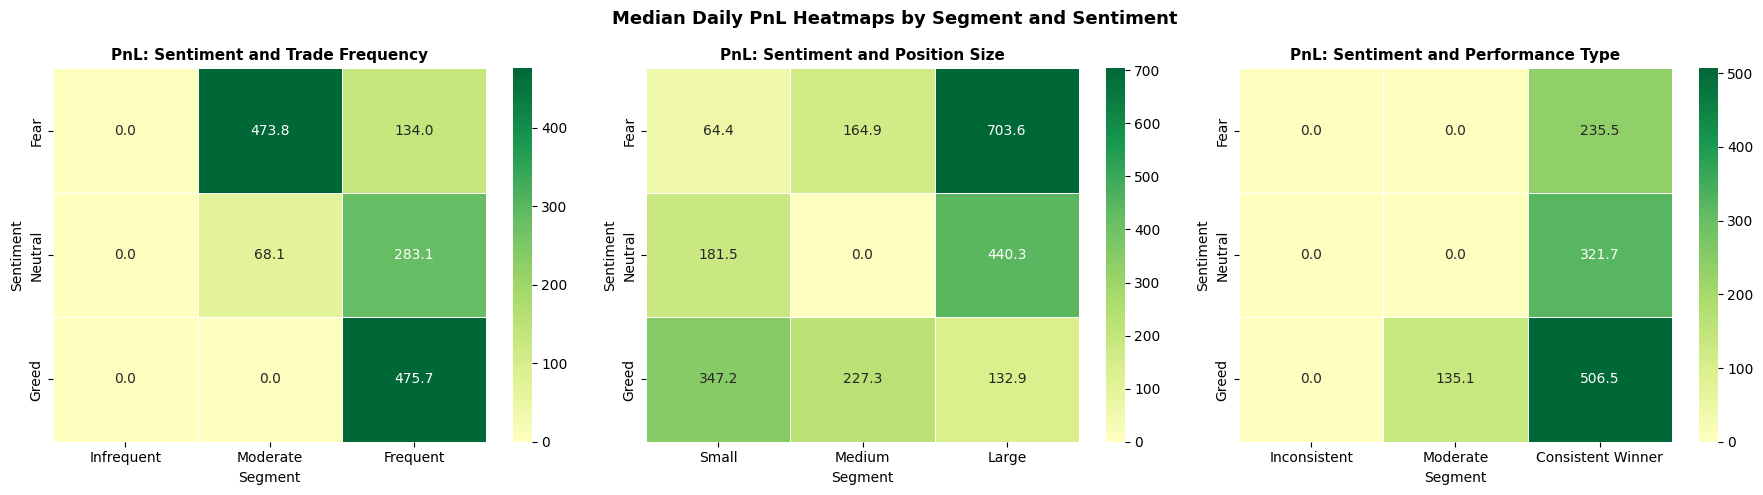

In [81]:
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

heatmap_data = [
    merged_dt.groupby(['sentiment_group', 'freq_segment'])['daily_pnl'].median().unstack().reindex(['Fear','Neutral','Greed']),
    merged_dt.groupby(['sentiment_group', 'size_segment'])['daily_pnl'].median().unstack().reindex(['Fear','Neutral','Greed']),
    merged_dt.groupby(['sentiment_group', 'perf_segment'])['daily_pnl'].median().unstack().reindex(['Fear','Neutral','Greed'])
]
titles = ['PnL: Sentiment and Trade Frequency', 'PnL: Sentiment and Position Size', 'PnL: Sentiment and Performance Type']

for i, (data, title) in enumerate(zip(heatmap_data, titles)):
    sns.heatmap(data, annot=True, fmt='.1f', cmap='RdYlGn',
                center=0, ax=axes[i], linewidths=0.5)
    axes[i].set_title(title, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Segment')
    axes[i].set_ylabel('Sentiment')

plt.suptitle('Median Daily PnL Heatmaps by Segment and Sentiment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart3_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

In [82]:
#summary table to support recommendations
strategy_table = merged_dt.groupby(['sentiment_group', 'size_segment']).agg(
    median_pnl=('daily_pnl', 'median'),
    median_win_rate=('win_rate', 'median'),
    median_trade_count=('trade_count', 'median')
).round(2)
print(strategy_table)

                              median_pnl  median_win_rate  median_trade_count
sentiment_group size_segment                                                 
Fear            Small              64.36             0.89                28.5
                Medium            164.87             0.96                33.0
                Large             703.63             1.00                34.0
Greed           Small             347.23             0.94                59.0
                Medium            227.32             0.89                23.0
                Large             132.86             0.98                16.5
Neutral         Small             181.46             0.94                41.0
                Medium              0.00             0.25                32.0
                Large             440.28             1.00                21.0


/tmp/ipykernel_6643/1399561616.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  strategy_table = merged_dt.groupby(['sentiment_group', 'size_segment']).agg(


In [84]:
#Bonus — Predictive Model

              precision    recall  f1-score   support

           0       0.58      0.38      0.46       188
           1       0.66      0.82      0.73       281

    accuracy                           0.64       469
   macro avg       0.62      0.60      0.60       469
weighted avg       0.63      0.64      0.62       469



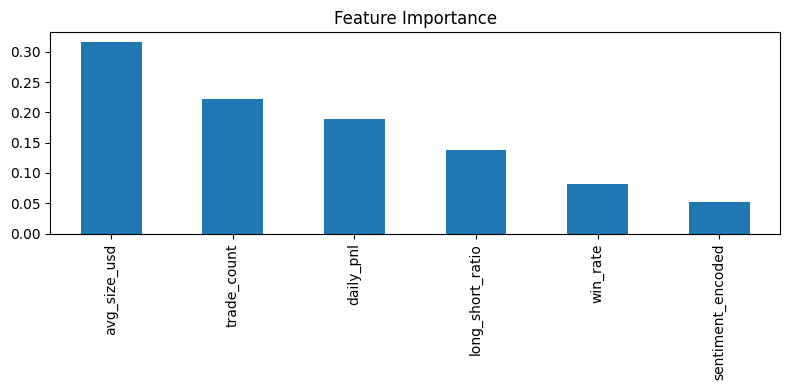

In [83]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

#was next day profitable?
merged_dt_sorted = merged_dt.sort_values(['Account', 'date'])
merged_dt_sorted['next_day_profitable'] = (
    merged_dt_sorted.groupby('Account')['daily_pnl'].shift(-1) > 0
).astype(int)


le = LabelEncoder()
merged_dt_sorted['sentiment_encoded'] = le.fit_transform(
    merged_dt_sorted['sentiment_group'].fillna('Neutral')
)

#features
features = ['sentiment_encoded', 'trade_count', 'avg_size_usd',
            'long_short_ratio', 'win_rate', 'daily_pnl']

model_df = merged_dt_sorted[features + ['next_day_profitable']].dropna()

X = model_df[features]
y = model_df['next_day_profitable']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))

#feature importance
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
importances.plot(kind='bar', figsize=(8,4), title='Feature Importance')
plt.tight_layout()
plt.savefig('chart4_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()